### My QuestiWhat is the typical number of streams for a hit song on Spotify in 2023? Specifically, what is the median number of streams in this dataset, and how does it compare to the mean?

This is an observational study. The songs were not assigned to any treatment and nothing was changed or controlled. The streams were simply recorded as they already happened. It is not a census, because the data only covers 953 popular songs, not every song on Spotify.

### Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("spotify-2023.csv", encoding="latin-1")
df["streams"] = pd.to_numeric(df["streams"], errors="coerce")
df = df.dropna(subset=["streams"])
df["streams_m"] = df["streams"] / 1e6

print(len(df), "songs")

952 songs


In [2]:
stats = df["streams_m"].describe(percentiles=[.25, .5, .75]).round(1)
stats

count     952.0
mean      514.1
std       566.9
min         0.0
25%       141.6
50%       290.5
75%       673.9
max      3703.9
Name: streams_m, dtype: float64

In [3]:
q1, med, q3 = df["streams_m"].quantile([.25, .5, .75])
mean = df["streams_m"].mean()
iqr = q3 - q1
outliers = (df["streams_m"] > q3 + 1.5 * iqr).sum()

print(f"Mean:   {mean:,.1f} M")
print(f"Median: {med:,.1f} M")
print(f"Q1: {q1:,.1f} M | Q3: {q3:,.1f} M | IQR: {iqr:,.1f} M")
print(f"Songs flagged as high outliers: {outliers}")

Mean:   514.1 M
Median: 290.5 M
Q1: 141.6 M | Q3: 673.9 M | IQR: 532.2 M
Songs flagged as high outliers: 74


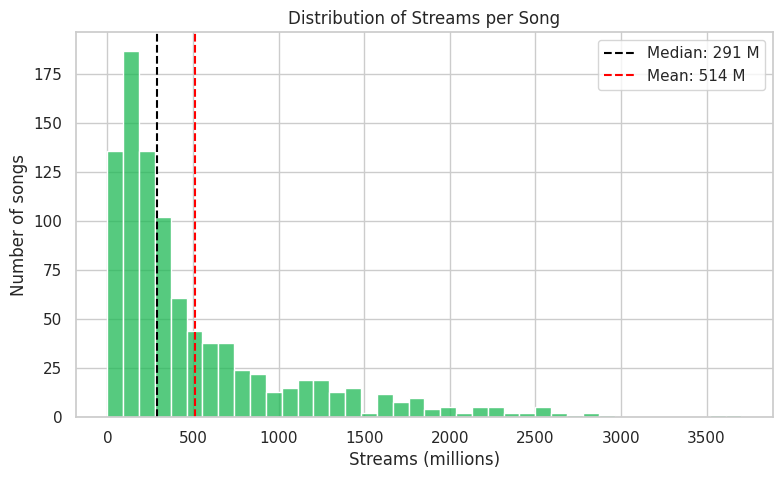

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["streams_m"], bins=40, color="#1DB954", ax=ax)
ax.axvline(med, color="black", linestyle="--", label=f"Median: {med:,.0f} M")
ax.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:,.0f} M")
ax.set_title("Distribution of Streams per Song")
ax.set_xlabel("Streams (millions)")
ax.set_ylabel("Number of songs")
ax.legend()
plt.show()

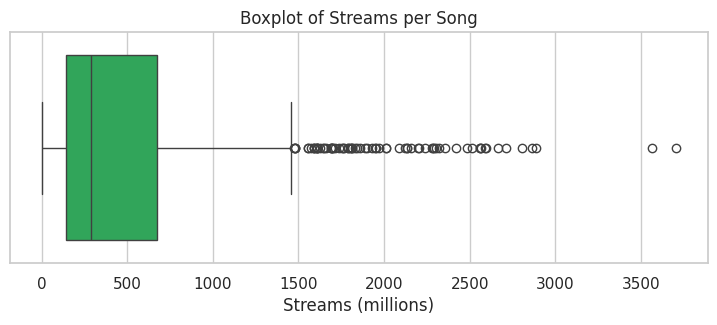

In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.boxplot(x=df["streams_m"], color="#1DB954", ax=ax)
ax.set_title("Boxplot of Streams per Song")
ax.set_xlabel("Streams (millions)")
plt.show()

### Conclusion
The median song in this dataset has about 290.5 million streams, while the mean is about 514 million. The middle 50% of songs fall between roughly 142 million (Q1) and 674 million (Q3) streams. The median is the better measure of a "typical" hit, because the mean is pulled upward by a small group of extremely popular songs.